# Confidence intervals — MKID (TiN), heavy mediator (F_DM = 1), m_DM = 100 MeV

Point-wise profile confidence bands of the recovered flux x(v_min), one
subsection per halo model. Method and conventions:
[`quantum_sensor.statistics.find_confidence_band`](../src/quantum_sensor/statistics.py)
(neutrinoAnalysis construction: observed profile Δχ² vs an MC-calibrated
cutoff; Poisson pseudo-experiments; CLARABEL solver, thread-parallel).

- Configuration: `material='TiN', q='0', mass='2', nbins=5`, background `none`
- Outputs per model: `results/MKID/bkg-none/<config>/` —
  `band/band_idx*.json` (primary, one per point), `flux_profile_band.csv`
  (summary), `flux_profile_band.pdf` (figure)
- **Each `run_model` cell takes ~30–60 min** (production MC settings).
  Already computed? Use `show_saved` in §Saved results instead.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_sensor import (DarkMatterQuantumAnalysis, RunConfig,
                            pointwise_band, load_pointwise_band,
                            band_table, save_band_products)
from quantum_sensor.plotting import plot_flux_with_pointwise_bands, run_dir

MATERIAL, Q, MASS, NBINS = 'TiN', '0', '2', 5
LEVELS = (0.68, 0.954)                                   # 1 sigma, 2 sigma
MC = dict(num_pseudo=50, n_pseudo_edge=500, rel_tol=0.02)  # production settings
N_INDICES = 30


def build(eta='Halo', disk_fraction=None):
    cfg = RunConfig(material=MATERIAL, q=Q, mass=MASS, nbins=NBINS,
                    eta=eta, disk_fraction=disk_fraction, background='none')
    a = DarkMatterQuantumAnalysis(cfg)
    a.optimize()
    return a


def run_model(eta='Halo', disk_fraction=None):
    """Compute, save and display the band for one halo model (heavy)."""
    a = build(eta, disk_fraction)
    print(f'{a.config}')
    print(f'counts per bin: {np.array2string(a.observed, precision=1)}')
    bands = pointwise_band(a, n_indices=N_INDICES, levels=LEVELS, **MC)
    save_band_products(a, bands)
    display(band_table(bands))
    return a, bands


def show_saved(eta='Halo', disk_fraction=None):
    """Reload a saved band (band/*.json) — no recomputation."""
    a = build(eta, disk_fraction)
    bands = load_pointwise_band(run_dir(a))
    print(f'{len(bands)} points from {run_dir(a) / "band"}')
    display(band_table(bands))
    plot_flux_with_pointwise_bands(a, bands, save=False)
    return a, bands


## 1. Standard halo (SHM)


In [ ]:
a_halo, b_halo = run_model(eta='Halo')


## 2. Pure dark disk


In [ ]:
a_disk, b_disk = run_model(eta='Disk')


## 3. Halo + dark-disk mixtures

The fit eta is `(1-p)·Halo + p·Disk` with the same total local DM density.


RunConfig(material='TiN', q='0', mass='2', nbins=5, eta='Halo', disk_fraction=0.05, background='none', run=None)
counts per bin: [140.  419.8 610.3 780.6 928.6]
[1/24] idx 0 (v=17 km/s)  best 4.52e-27 cm^-1  1sigma [4.27e-27, 6.09e-23]  2sigma [4.11e-27, 1.43e-22]  (49 evals)
[2/24] idx 1 (v=18 km/s)  best 4.52e-27 cm^-1  1sigma [4.27e-27, 9.56e-25]  2sigma [4.06e-27, 2.23e-24]  (36 evals)
[3/24] idx 2 (v=19 km/s)  best 4.52e-27 cm^-1  1sigma [4.27e-27, 2.11e-25]  2sigma [4.06e-27, 3.88e-25]  (34 evals)
[4/24] idx 3 (v=20 km/s)  best 4.52e-27 cm^-1  1sigma [4.27e-27, 5.18e-26]  2sigma [4.06e-27, 1.14e-25]  (28 evals)
[5/24] idx 4 (v=21 km/s)  best 4.52e-27 cm^-1  1sigma [4.27e-27, 2.13e-26]  2sigma [4.06e-27, 4.73e-26]  (27 evals)
[6/24] idx 6 (v=22 km/s)  best 4.52e-27 cm^-1  1sigma [4.27e-27, 8.88e-27]  2sigma [4.06e-27, 1.51e-26]  (23 evals)
[7/24] idx 7 (v=23 km/s)  best 4.52e-27 cm^-1  1sigma [4.27e-27, 7.95e-27]  2sigma [4.06e-27, 1.01e-26]  (21 evals)
[8/24] idx 9 (v=25 km/s)  b

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,17.4,4.521614e-27,4.271096e-27,6.085969e-23,4.111789e-27,1.430304e-22,-6%,+1345873%,49
1,1,18.2,4.521614e-27,4.271096e-27,9.555581e-25,4.060018e-27,2.233306e-24,-6%,+21033%,36
2,2,19.0,4.521614e-27,4.271096e-27,2.107200e-25,4.060018e-27,3.877310e-25,-6%,+4560%,34
3,3,19.8,4.521614e-27,4.271096e-27,5.183238e-26,4.060018e-27,1.137046e-25,-6%,+1046%,28
4,4,20.6,4.521614e-27,4.271096e-27,2.128319e-26,4.060018e-27,4.728424e-26,-6%,+371%,27
5,6,22.2,4.521614e-27,4.271096e-27,8.878507e-27,4.060018e-27,1.511679e-26,-6%,+96%,23
6,7,23.0,4.521614e-27,4.271096e-27,7.946558e-27,4.060018e-27,1.010958e-26,-6%,+76%,21
7,9,24.6,4.521614e-27,4.271096e-27,6.090027e-27,4.060018e-27,8.254440e-27,-6%,+35%,22
8,11,26.2,4.521614e-27,4.271096e-27,5.433673e-27,4.060018e-27,6.739722e-27,-6%,+20%,20
9,13,27.8,4.521614e-27,4.217319e-27,5.165140e-27,4.060018e-27,6.246330e-27,-7%,+14%,20


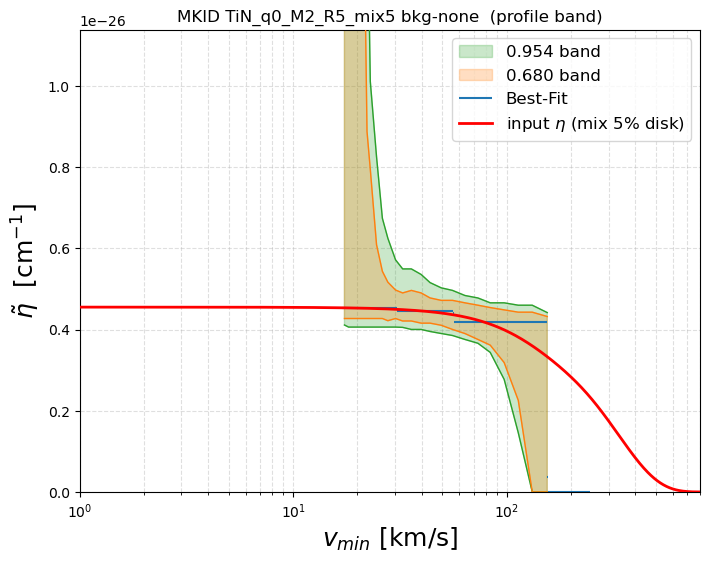

In [4]:
a_mix5, b_mix5 = run_model(disk_fraction=0.05)    # 5% disk


RunConfig(material='TiN', q='0', mass='2', nbins=5, eta='Halo', disk_fraction=0.25, background='none', run=None)
counts per bin: [ 182.6  537.3  752.   913.3 1022.1]
[1/24] idx 0 (v=17 km/s)  best 5.93e-27 cm^-1  1sigma [5.53e-27, 7.89e-23]  2sigma [5.32e-27, 1.78e-22]  (51 evals)
[2/24] idx 1 (v=18 km/s)  best 5.93e-27 cm^-1  1sigma [5.53e-27, 1.22e-24]  2sigma [5.19e-27, 2.82e-24]  (36 evals)
[3/24] idx 2 (v=19 km/s)  best 5.93e-27 cm^-1  1sigma [5.53e-27, 2.58e-25]  2sigma [5.19e-27, 5.08e-25]  (34 evals)
[4/24] idx 3 (v=20 km/s)  best 5.93e-27 cm^-1  1sigma [5.53e-27, 6.22e-26]  2sigma [5.19e-27, 1.45e-25]  (28 evals)
[5/24] idx 4 (v=21 km/s)  best 5.93e-27 cm^-1  1sigma [5.53e-27, 2.9e-26]  2sigma [5.19e-27, 5.74e-26]  (27 evals)
[6/24] idx 5 (v=21 km/s)  best 5.93e-27 cm^-1  1sigma [5.53e-27, 1.62e-26]  2sigma [5.19e-27, 2.98e-26]  (24 evals)
[7/24] idx 6 (v=22 km/s)  best 5.93e-27 cm^-1  1sigma [5.53e-27, 1.15e-26]  2sigma [5.19e-27, 2.06e-26]  (24 evals)
[8/24] idx 8 (v=24 km/s

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,17.4,5.925111e-27,5.526365e-27,7.893356e-23,5.320237e-27,1.780230e-22,-7%,+1332087%,51
1,1,18.2,5.925111e-27,5.526365e-27,1.220828e-24,5.187108e-27,2.817362e-24,-7%,+20504%,36
2,2,19.0,5.925111e-27,5.526365e-27,2.575391e-25,5.187108e-27,5.080818e-25,-7%,+4247%,34
3,3,19.8,5.925111e-27,5.526365e-27,6.215617e-26,5.187108e-27,1.452698e-25,-7%,+949%,28
4,4,20.6,5.925111e-27,5.526365e-27,2.896999e-26,5.187108e-27,5.742517e-26,-7%,+389%,27
5,5,21.4,5.925111e-27,5.526365e-27,1.622490e-26,5.187108e-27,2.980704e-26,-7%,+174%,24
6,6,22.2,5.925111e-27,5.526365e-27,1.152405e-26,5.187108e-27,2.064126e-26,-7%,+94%,24
7,8,23.8,5.925111e-27,5.526365e-27,8.610718e-27,5.187108e-27,1.227776e-26,-7%,+45%,22
8,9,24.6,5.925111e-27,5.526365e-27,7.780662e-27,5.187108e-27,1.028204e-26,-7%,+31%,22
9,11,26.2,5.925111e-27,5.526365e-27,6.942100e-27,5.187108e-27,8.720517e-27,-7%,+17%,20


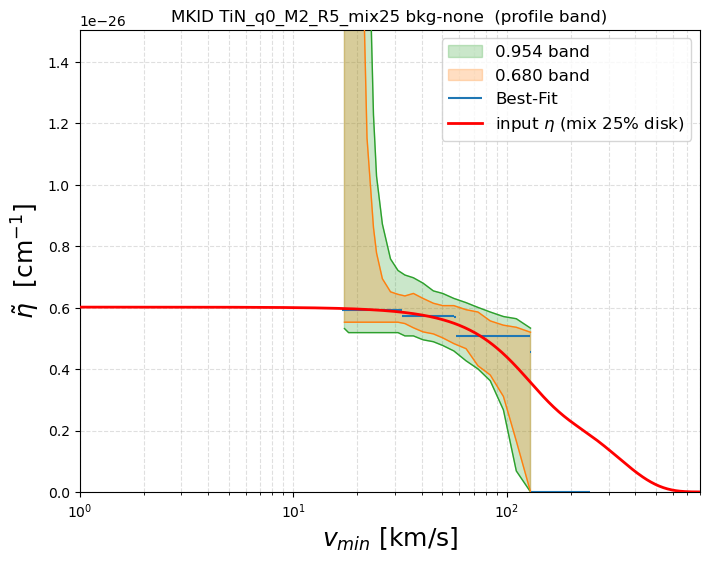

In [2]:
a_mix25, b_mix25 = run_model(disk_fraction=0.25)  # 25% disk


## Saved results (no recomputation)

Reload any model computed above (or in a previous session).


25 points from /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/band


,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,17.4,4.180242e-27,3.948638e-27,5.886500e-23,3.849831e-27,1.045214e-22,-6%,+1408072%,33
1,1,18.2,4.180242e-27,3.948638e-27,8.113192e-25,3.801358e-27,1.819695e-24,-6%,+19308%,38
2,2,19.0,4.180242e-27,3.948638e-27,1.784189e-25,3.801358e-27,4.196463e-25,-6%,+4168%,31
3,3,19.8,4.180242e-27,3.948638e-27,4.487097e-26,3.801358e-27,1.011197e-25,-6%,+973%,31
4,4,20.6,4.180242e-27,3.948638e-27,2.074794e-26,3.801358e-27,4.409554e-26,-6%,+396%,29
5,5,21.4,4.180242e-27,3.948638e-27,1.219554e-26,3.801358e-27,2.102925e-26,-6%,+192%,22
6,6,22.2,4.180242e-27,3.948638e-27,8.689820e-27,3.801358e-27,1.397551e-26,-6%,+108%,21
7,7,23.0,4.180242e-27,3.948638e-27,7.050399e-27,3.849831e-27,1.091596e-26,-6%,+69%,22
8,9,24.6,4.180242e-27,3.948638e-27,5.559354e-27,3.801358e-27,7.827108e-27,-6%,+33%,20
9,11,26.2,4.180242e-27,3.948638e-27,4.960194e-27,3.801358e-27,6.390807e-27,-6%,+19%,20


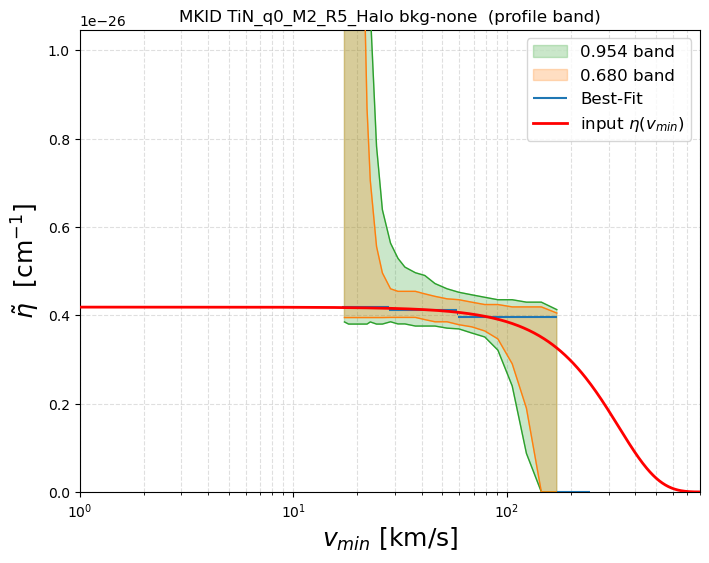

In [3]:
show_saved(eta='Halo');
# show_saved(eta='Disk');
# show_saved(disk_fraction=0.05);
# show_saved(disk_fraction=0.25);
